# Data Visualization in Python
## Workshop: Matplotlib & Seaborn with the Gapminder Dataset

**Audience:** Graduate students, postdocs, staff, and faculty  
**Prerequisites:** Basic Python and pandas familiarity  

---

### What you'll learn

- The relationship between **matplotlib** and **seaborn** — and when to use each
- How to build and customize common chart types: scatter, line, bar, histogram, box, and heatmap
- How to use **color**, **faceting**, and **annotations** to communicate clearly
- How to save publication-quality figures

### The dataset

We'll use the [Gapminder dataset](https://www.gapminder.org/), which tracks life expectancy, population, and GDP per capita for ~140 countries from 1952 to 2007.

| Column | Description |
|--------|-------------|
| `country` | Country name |
| `continent` | Continent |
| `year` | Year (1952–2007, every 5 years) |
| `lifeExp` | Life expectancy at birth (years) |
| `pop` | Population |
| `gdpPercap` | GDP per capita (inflation-adjusted USD) |

---
## 1. Setup and Data Loading

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Work with a copy
gapminder_csvpath = Path("../../../data/gapminder.csv")
df = pd.read_csv(gapminder_csvpath)

print(f"Shape: {df.shape}")
df.head()

Shape: (1704, 6)


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [14]:
# Quick overview
print("Years covered:", sorted(df['year'].unique()))
print("Continents:", sorted(df['continent'].unique()))
print("Number of countries:", df['country'].nunique())
df.describe()

Years covered: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']
Number of countries: 142


,year,lifeExp,pop,gdpPercap
count,1704.00000,1704.000000,1.704000e+03,1704.000000
mean,1979.50000,59.474439,2.960121e+07,7215.327081
std,17.26533,12.917107,1.061579e+08,9857.454543
min,1952.00000,23.599000,6.001100e+04,241.165876
25%,1965.75000,48.198000,2.793664e+06,1202.060309
50%,1979.50000,60.712500,7.023596e+06,3531.846988
75%,1993.25000,70.845500,1.958522e+07,9325.462346
max,2007.00000,82.603000,1.318683e+09,113523.132900


### The matplotlib / seaborn relationship

Think of them as two layers:

```
┌─────────────────────────────────────┐
│  seaborn  — high-level, opinionated │  ← start here
│  (statistical charts, themes)       │
├─────────────────────────────────────┤
│  matplotlib — low-level, flexible   │  ← customize here
│  (axes, ticks, labels, layout)      │
└─────────────────────────────────────┘
```

Seaborn figures are matplotlib figures — you can always drop down to `plt` or `ax` calls to fine-tune anything.

---
## 2. Figure Architecture: `fig` and `ax`

The two core matplotlib objects:
- **`fig`** (`Figure`) — the whole canvas
- **`ax`** (`Axes`) — a single plot panel; one figure can contain many axes

Always create them explicitly when you want control.

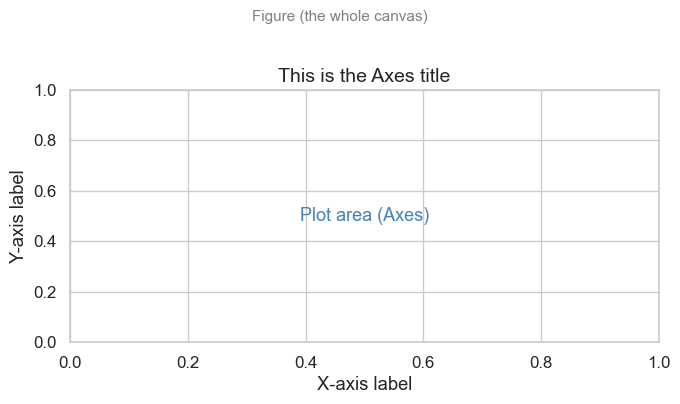

In [15]:
# Anatomy of a matplotlib figure
fig, ax = plt.subplots(figsize=(7, 4))

ax.set_title("This is the Axes title", fontsize=14)
ax.set_xlabel("X-axis label")
ax.set_ylabel("Y-axis label")
ax.text(0.5, 0.5, "Plot area (Axes)",
        ha='center', va='center', fontsize=13, color='steelblue',
        transform=ax.transAxes)
fig.suptitle("Figure (the whole canvas)", y=1.01, fontsize=11, color='gray')

plt.tight_layout()
plt.show()

---
## 3. Seaborn Themes and Color Palettes

Before plotting real data, set a theme. This improves aesthetics globally.

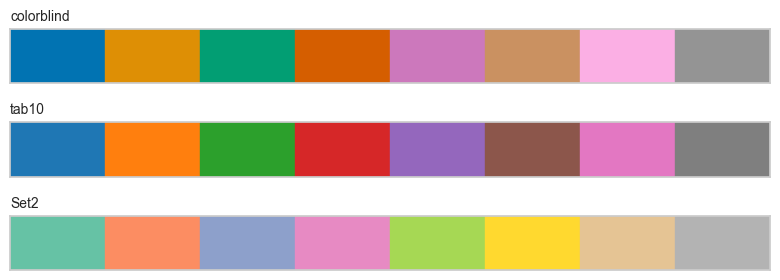

In [16]:
# Available themes: darkgrid, whitegrid, dark, white, ticks
sns.set_theme(style='whitegrid', palette='colorblind', font_scale=1.1)

# Preview some palettes
# sns.palplot() is a legacy function that doesn't support subplots,
# so we draw swatches manually using matplotlib patches.
palettes = ['colorblind', 'tab10', 'Set2']
n_colors = 8

fig, axes = plt.subplots(len(palettes), 1, figsize=(8, 3))
for ax, pal in zip(axes, palettes):
    colors = sns.color_palette(pal, n_colors)
    for i, color in enumerate(colors):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
    ax.set_xlim(0, n_colors)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(pal, loc='left', fontsize=10)

plt.tight_layout()
plt.show()


> **Accessibility tip:** `colorblind` (also called `"colorblind"` or `sns.color_palette("colorblind")`) is safe for the most common forms of color vision deficiency. Prefer it for presentations and publications.

---
## 4. Scatter Plot — Relationship Between Two Variables

**Research question:** Is there a relationship between wealth (GDP per capita) and health (life expectancy)?

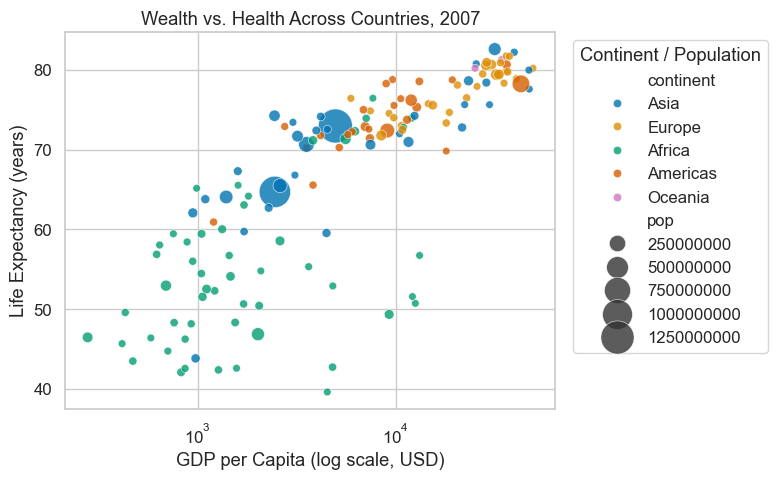

In [17]:
# Filter to the most recent year
df_2007 = df[df['year'] == 2007].copy()

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=df_2007,
    x='gdpPercap',
    y='lifeExp',
    hue='continent',   # color by continent
    size='pop',        # dot size by population
    sizes=(30, 600),   # min and max dot size in points^2
    alpha=0.8,
    ax=ax
)

ax.set_xscale('log')   # GDP spans orders of magnitude — log scale helps
ax.set_xlabel('GDP per Capita (log scale, USD)')
ax.set_ylabel('Life Expectancy (years)')
ax.set_title('Wealth vs. Health Across Countries, 2007')

# Move legend outside the plot
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Continent / Population')

plt.tight_layout()
plt.show()

**What to notice:**
- A clear positive relationship — wealthier countries tend to have longer life expectancy.
- The relationship is not linear: gains in life expectancy diminish at higher incomes (hence the log scale).
- Africa (purple) clusters in the lower-left; Europe and Oceania cluster upper-right.

---
## 5. Line Plot — Change Over Time

**Research question:** How has global life expectancy changed by continent from 1952 to 2007?

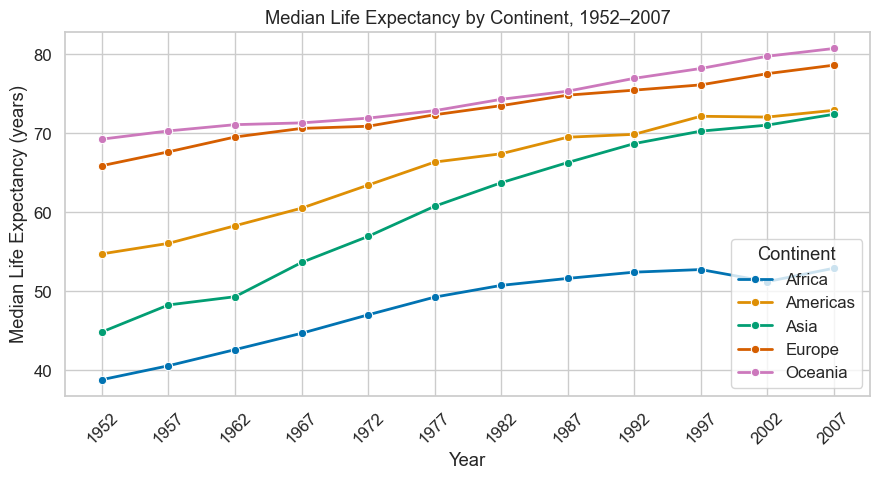

In [18]:
# Aggregate: median life expectancy per continent per year
df_continent_year = (
    df.groupby(['continent', 'year'])['lifeExp']
    .median()
    .reset_index()
    .rename(columns={'lifeExp': 'medianLifeExp'})
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=df_continent_year,
    x='year',
    y='medianLifeExp',
    hue='continent',
    marker='o',       # dot at each data point
    linewidth=2,
    ax=ax
)

ax.set_xlabel('Year')
ax.set_ylabel('Median Life Expectancy (years)')
ax.set_title('Median Life Expectancy by Continent, 1952–2007')
ax.legend(title='Continent')

# Custom x-axis ticks
ax.set_xticks(df['year'].unique())
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**What to notice:**
- Every continent shows improvement over time.
- Africa's gains stall in the 1990s — reflecting the HIV/AIDS epidemic.
- Oceania and Europe converge toward high life expectancy by 2007.

---
## 6. Bar Chart — Comparing Groups

**Research question:** How does average GDP per capita differ by continent in 2007?

C:\Users\F0040RP\AppData\Local\Temp\ipykernel_43872\1564277103.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


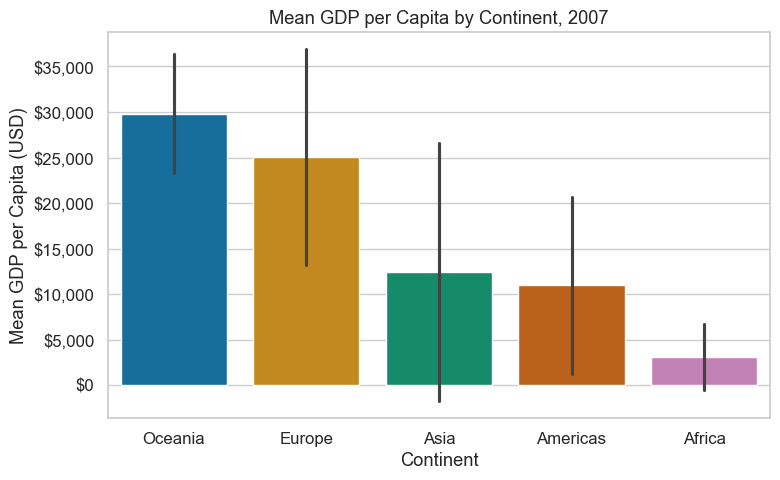

In [19]:
# Sort continents by mean GDP
continent_order = (
    df_2007.groupby('continent')['gdpPercap']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=df_2007,
    x='continent',
    y='gdpPercap',
    order=continent_order,
    estimator='mean',      # plot the mean
    errorbar='sd',         # error bars = 1 standard deviation
    palette='colorblind',
    ax=ax
)

ax.set_xlabel('Continent')
ax.set_ylabel('Mean GDP per Capita (USD)')
ax.set_title('Mean GDP per Capita by Continent, 2007')

# Format y-axis with commas
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

> **Design note:** Error bars here show one standard deviation — they describe *spread* in the data, not uncertainty in the mean. Always label what your error bars represent.

---
## 7. Histogram and KDE — Distributions

**Research question:** What does the distribution of life expectancy look like in 2007? Has it changed since 1952?

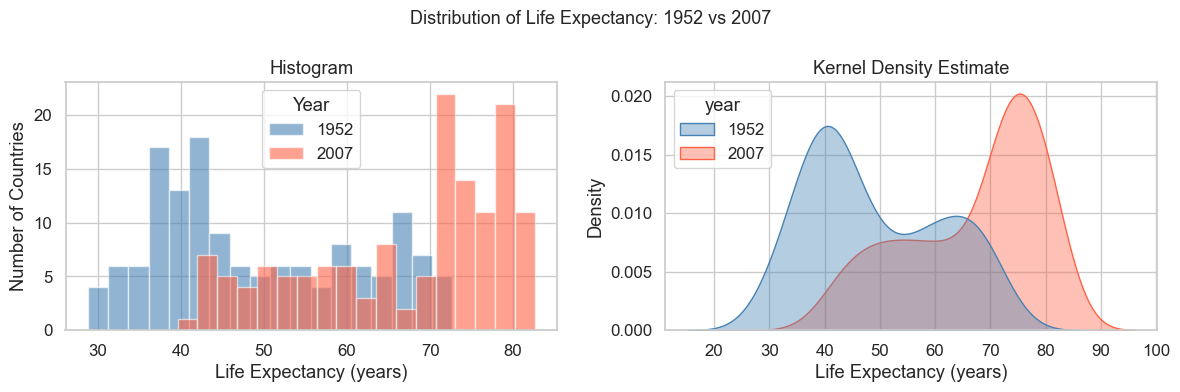

In [20]:
df_compare = df[df['year'].isin([1952, 2007])].copy()
df_compare['year'] = df_compare['year'].astype(str)  # treat as category

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: overlapping histograms
for yr, color in zip(['1952', '2007'], ['steelblue', 'tomato']):
    subset = df_compare[df_compare['year'] == yr]
    axes[0].hist(subset['lifeExp'], bins=18, alpha=0.6, label=yr, color=color, edgecolor='white')
axes[0].set_xlabel('Life Expectancy (years)')
axes[0].set_ylabel('Number of Countries')
axes[0].set_title('Histogram')
axes[0].legend(title='Year')

# Right: KDE (smooth density estimate)
sns.kdeplot(
    data=df_compare,
    x='lifeExp',
    hue='year',
    fill=True,
    alpha=0.4,
    palette=['steelblue', 'tomato'],
    ax=axes[1]
)
axes[1].set_xlabel('Life Expectancy (years)')
axes[1].set_ylabel('Density')
axes[1].set_title('Kernel Density Estimate')

fig.suptitle('Distribution of Life Expectancy: 1952 vs 2007', fontsize=13)
plt.tight_layout()
plt.show()

**What to notice:**
- In 1952, the distribution is broad and somewhat bimodal — a rich-poor gap in health outcomes.
- By 2007, the distribution has shifted right and become more concentrated — global convergence in life expectancy.

---
## 8. Box Plot and Violin Plot — Distributions Across Groups

C:\Users\F0040RP\AppData\Local\Temp\ipykernel_43872\585384550.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\F0040RP\AppData\Local\Temp\ipykernel_43872\585384550.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


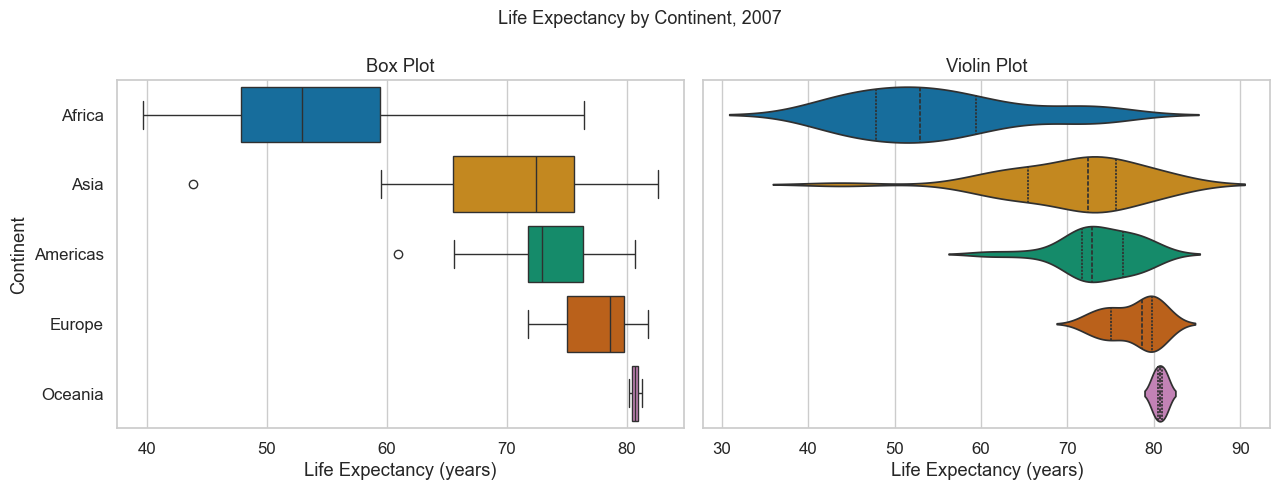

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

continent_order_life = (
    df_2007.groupby('continent')['lifeExp']
    .median()
    .sort_values()
    .index.tolist()
)

# Box plot
sns.boxplot(
    data=df_2007, x='lifeExp', y='continent',
    order=continent_order_life,
    palette='colorblind', ax=axes[0]
)
axes[0].set_title('Box Plot')
axes[0].set_xlabel('Life Expectancy (years)')
axes[0].set_ylabel('Continent')

# Violin plot
sns.violinplot(
    data=df_2007, x='lifeExp', y='continent',
    order=continent_order_life,
    palette='colorblind', inner='quartile', ax=axes[1]
)
axes[1].set_title('Violin Plot')
axes[1].set_xlabel('Life Expectancy (years)')
axes[1].set_ylabel('')

fig.suptitle('Life Expectancy by Continent, 2007', fontsize=13)
plt.tight_layout()
plt.show()

**Box vs. Violin:**
| | Box plot | Violin plot |
|---|---|---|
| Shows | Median, IQR, outliers | Full distribution shape |
| Good when | You want summary stats | You want to see modality/skew |
| Risk | Hides shape | Can mislead with small samples |

---
## 9. Faceting — Small Multiples with `FacetGrid`

Faceting creates a grid of plots — one per category — enabling easy comparison. This is one of seaborn's most powerful features.

**Research question:** Does the GDP–life expectancy relationship look the same across continents?

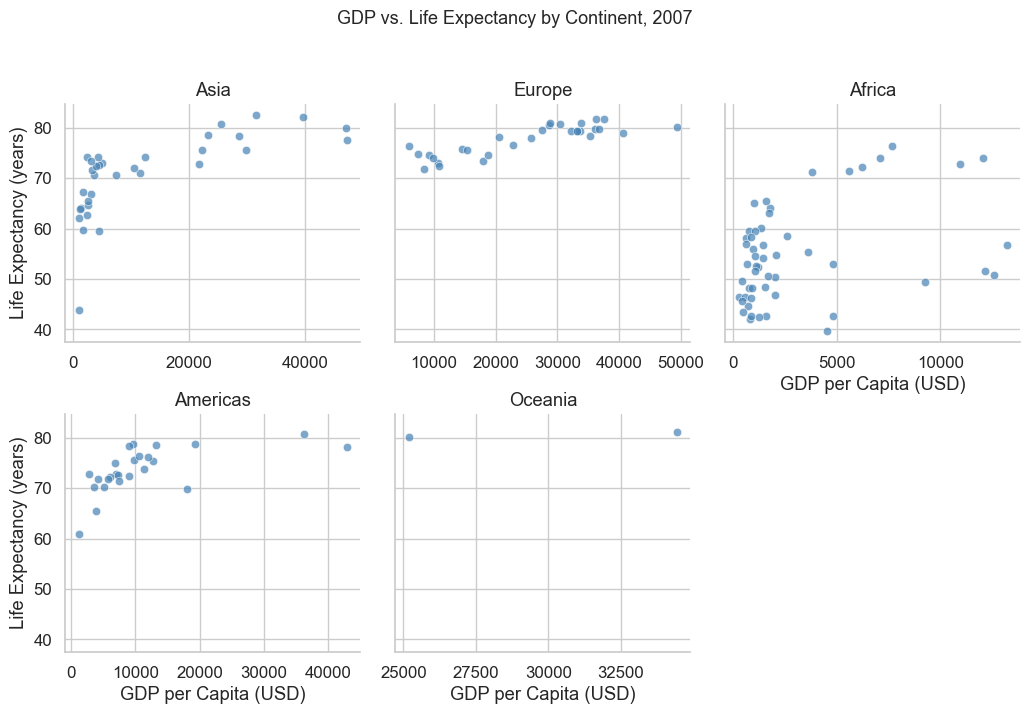

In [22]:
g = sns.FacetGrid(
    data=df_2007,
    col='continent',
    col_wrap=3,        # wrap into a new row after 3 columns
    height=3.5,
    sharey=True,       # same y-axis across panels
    sharex=False       # x-axis can differ
)

g.map_dataframe(
    sns.scatterplot,
    x='gdpPercap', y='lifeExp',
    alpha=0.7, color='steelblue'
)

g.set_axis_labels('GDP per Capita (USD)', 'Life Expectancy (years)')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('GDP vs. Life Expectancy by Continent, 2007',
                   y=1.02, fontsize=13)

plt.tight_layout()
plt.show()

---
## 10. Heatmap — Patterns in a Matrix

**Research question:** How has life expectancy changed over time for each continent? (Aggregated summary matrix)

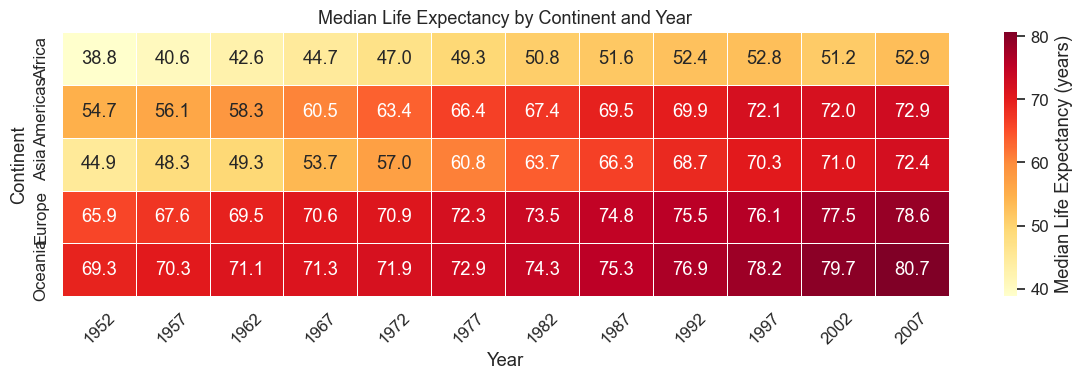

In [23]:
# Build a pivot table: rows = continent, columns = year, values = median life expectancy
pivot = (
    df.groupby(['continent', 'year'])['lifeExp']
    .median()
    .unstack('year')
    .round(1)
)

fig, ax = plt.subplots(figsize=(12, 4))

sns.heatmap(
    pivot,
    annot=True,         # show values in cells
    fmt='.1f',
    cmap='YlOrRd',      # yellow → orange → red = low → high
    linewidths=0.5,
    cbar_kws={'label': 'Median Life Expectancy (years)'},
    ax=ax
)

ax.set_title('Median Life Expectancy by Continent and Year', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Continent')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 11. Annotations — Drawing Attention to What Matters

A chart is a communication tool. Annotations guide the reader to the most important insight.

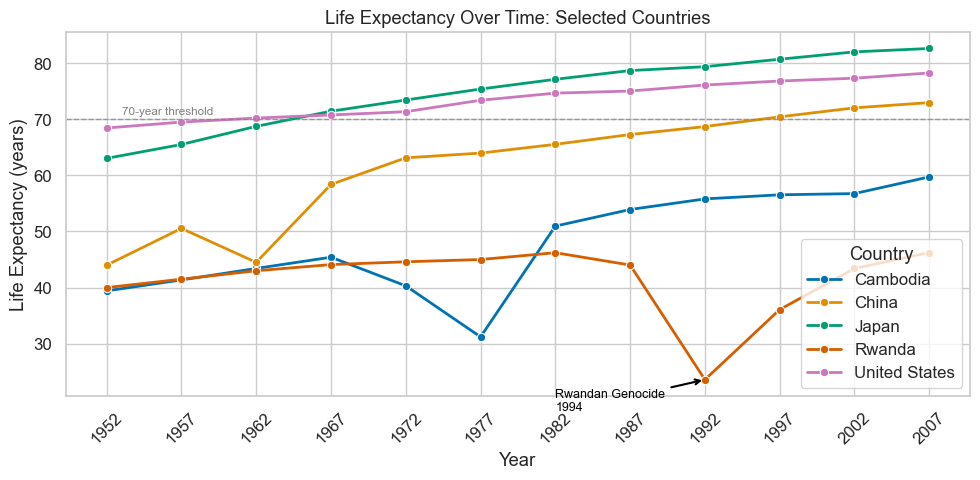

In [24]:
# Life expectancy over time for selected countries
countries = ['Rwanda', 'Cambodia', 'China', 'United States', 'Japan']
df_sel = df[df['country'].isin(countries)]

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=df_sel, x='year', y='lifeExp',
    hue='country', marker='o', linewidth=2, ax=ax
)

# --- Annotations ---

# Arrow pointing to Rwanda's 1992 collapse
ax.annotate(
    'Rwandan Genocide\n1994',
    xy=(1992, 23.6),           # tip of arrow (data coords)
    xytext=(1982, 18),         # label position
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    fontsize=9, color='black'
)

# Horizontal reference line
ax.axhline(y=70, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(1953, 70.8, '70-year threshold', fontsize=8.5, color='gray')

ax.set_xlabel('Year')
ax.set_ylabel('Life Expectancy (years)')
ax.set_title('Life Expectancy Over Time: Selected Countries')
ax.set_xticks(df['year'].unique())
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Country')

plt.tight_layout()
plt.show()

---
## 12. Subplots — Composing Multi-Panel Figures

Use `plt.subplots()` to build dashboard-style layouts combining multiple chart types.

C:\Users\F0040RP\AppData\Local\Temp\ipykernel_43872\1600965016.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2007, x='continent', y='gdpPercap',


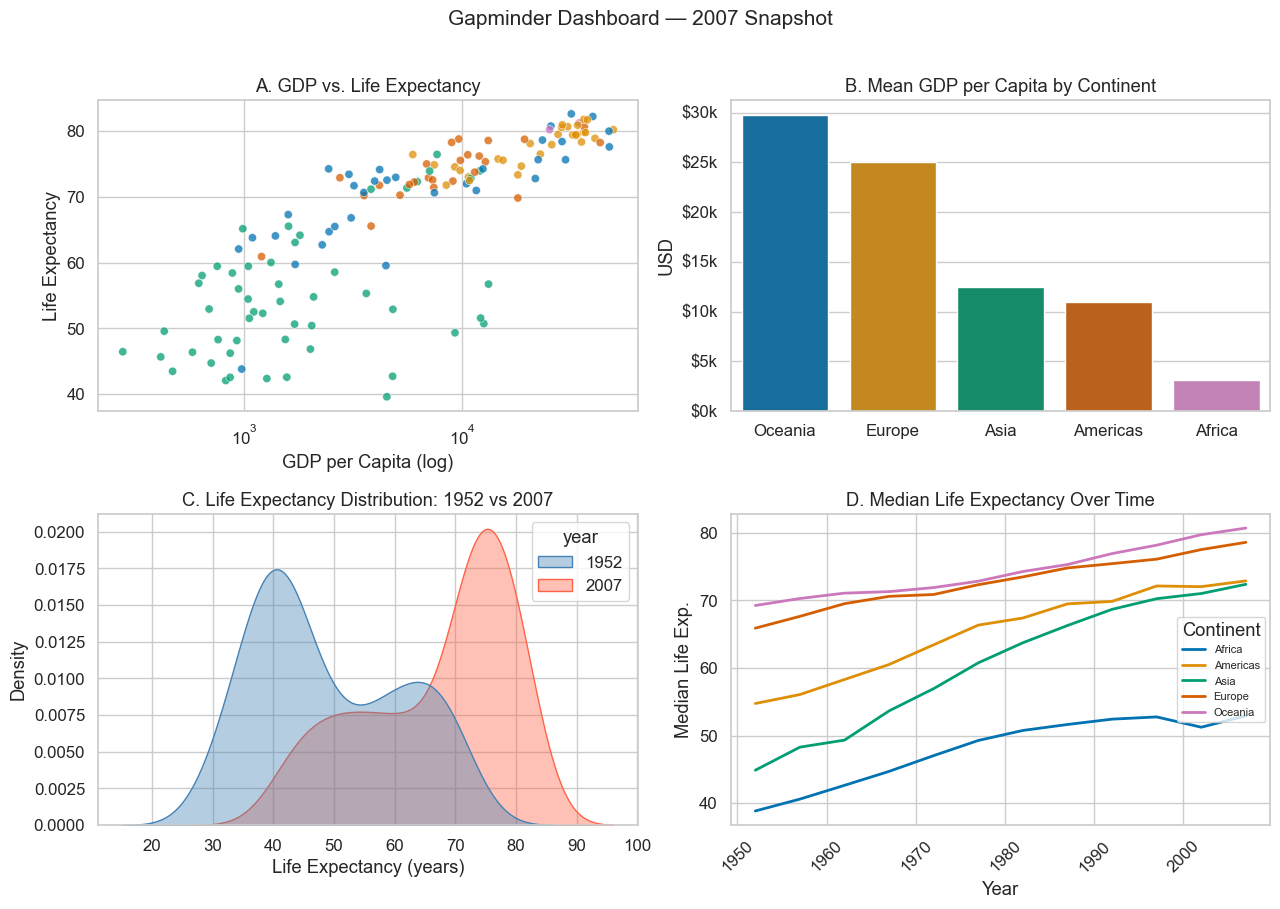

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Gapminder Dashboard — 2007 Snapshot', fontsize=15, y=1.01)

# ── Panel A: Scatter (GDP vs life expectancy) ──────────────────────────
ax = axes[0, 0]
sns.scatterplot(data=df_2007, x='gdpPercap', y='lifeExp',
                hue='continent', alpha=0.75, ax=ax, legend=False)
ax.set_xscale('log')
ax.set_title('A. GDP vs. Life Expectancy')
ax.set_xlabel('GDP per Capita (log)')
ax.set_ylabel('Life Expectancy')

# ── Panel B: Bar (GDP by continent) ───────────────────────────────────
ax = axes[0, 1]
sns.barplot(data=df_2007, x='continent', y='gdpPercap',
            order=continent_order, palette='colorblind',
            errorbar=None, ax=ax)
ax.set_title('B. Mean GDP per Capita by Continent')
ax.set_xlabel('')
ax.set_ylabel('USD')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# ── Panel C: Distribution of life expectancy ──────────────────────────
ax = axes[1, 0]
sns.kdeplot(data=df_compare, x='lifeExp', hue='year',
            fill=True, alpha=0.4, palette=['steelblue','tomato'], ax=ax)
ax.set_title('C. Life Expectancy Distribution: 1952 vs 2007')
ax.set_xlabel('Life Expectancy (years)')

# ── Panel D: Trend lines by continent ─────────────────────────────────
ax = axes[1, 1]
sns.lineplot(data=df_continent_year, x='year', y='medianLifeExp',
             hue='continent', ax=ax, linewidth=2)
ax.set_title('D. Median Life Expectancy Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Median Life Exp.')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Continent', fontsize=8)

plt.tight_layout()
plt.show()

---
## 13. Saving Figures

Always save *before* `plt.show()` — after `show()`, the figure is cleared from memory.

Saved as PNG, SVG, and PDF.


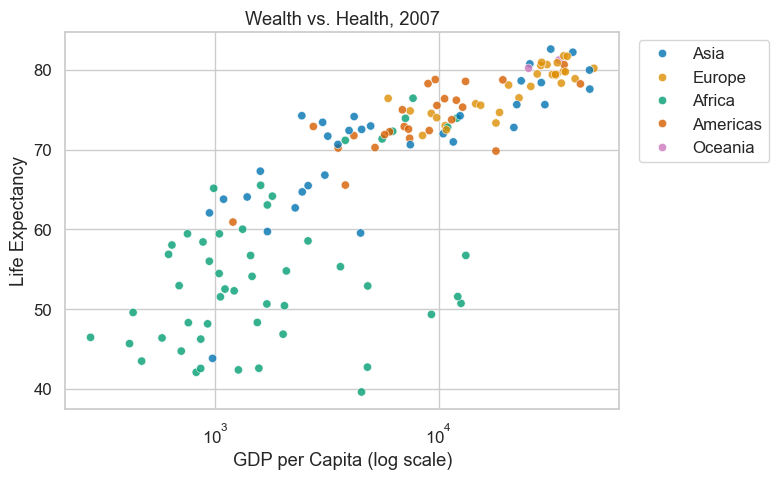

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_2007, x='gdpPercap', y='lifeExp',
                hue='continent', alpha=0.8, ax=ax)
ax.set_xscale('log')
ax.set_title('Wealth vs. Health, 2007')
ax.set_xlabel('GDP per Capita (log scale)')
ax.set_ylabel('Life Expectancy')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

# Save in multiple formats
fig.savefig('gapminder_scatter.png', dpi=300, bbox_inches='tight')  # for screen/web
fig.savefig('gapminder_scatter.svg', bbox_inches='tight')            # vector, for print
fig.savefig('gapminder_scatter.pdf', bbox_inches='tight')            # for LaTeX/papers

print("Saved as PNG, SVG, and PDF.")
plt.show()

| Format | Best for | Scales? |
|--------|----------|---------|
| PNG | Web, slides, email | No (raster) |
| SVG | Web, reports | Yes (vector) |
| PDF | Publications, LaTeX | Yes (vector) |

Use `dpi=300` for print-quality PNGs.

---
## 14. Quick Reference

### Choosing the right chart

| Goal | Chart type | Seaborn function |
|------|-----------|------------------|
| Relationship between 2 numeric vars | Scatter | `sns.scatterplot()` |
| Change over time | Line | `sns.lineplot()` |
| Compare group totals | Bar | `sns.barplot()` |
| Distribution of one variable | Histogram / KDE | `ax.hist()` / `sns.kdeplot()` |
| Distribution across groups | Box / Violin | `sns.boxplot()` / `sns.violinplot()` |
| Matrix of values | Heatmap | `sns.heatmap()` |
| Compare subgroups side-by-side | Facets | `sns.FacetGrid()` |

### Most-used customizations

```python
# Titles and labels
ax.set_title('...')       # axes title
ax.set_xlabel('...')      # x-axis label
ax.set_ylabel('...')      # y-axis label
fig.suptitle('...')       # figure-level title

# Axes limits and scale
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xscale('log')

# Ticks
ax.set_xticks([...])      # set specific tick positions
ax.tick_params(axis='x', rotation=45)

# Legend
ax.legend(title='...', bbox_to_anchor=(1.02, 1), loc='upper left')

# Annotations
ax.axhline(y=..., color='gray', linestyle='--')
ax.axvline(x=..., color='gray', linestyle='--')
ax.annotate('text', xy=(x, y), xytext=(xt, yt), arrowprops=dict(arrowstyle='->'))

# Layout and saving
plt.tight_layout()
fig.savefig('output.png', dpi=300, bbox_inches='tight')
```

---
## 15. Exercises

Try these on your own to consolidate what you've learned.

**Exercise 1 — Line plot**  
Plot the total world population over time (sum across all countries per year). Add a vertical dashed line at year 1987 and annotate it with the label "5 billion people".

**Exercise 2 — Grouped bar chart**  
Create a bar chart showing mean life expectancy for each continent in *both* 1952 and 2007 side by side. *(Hint: use `hue='year'` after filtering to those two years.)*

**Exercise 3 — Faceted scatter plot**  
Use `FacetGrid` to create one scatter plot of `gdpPercap` vs `lifeExp` for each year in the dataset (all 12 years). Set `col_wrap=4`.

**Exercise 4 — Customization challenge**  
Recreate the scatter plot from Section 4 but:
- Use a different seaborn theme
- Format the x-axis tick labels as `$10k`, `$20k`, etc.
- Add a subtitle using `fig.text()`
- Save the figure as a 300 dpi PNG

**Stretch exercise — Your own question**  
Identify a question about the Gapminder data you find interesting. Choose an appropriate chart type, build it, and write a 1–2 sentence interpretation below the chart.

In [27]:
# Your code here


---
## Further Reading

- **Seaborn docs:** https://seaborn.pydata.org — the gallery is an excellent starting point
- **Matplotlib docs:** https://matplotlib.org/stable/gallery
- **Fundamentals of Data Visualization** (Claus Wilke) — free online: https://clauswilke.com/dataviz/
- **The Visual Display of Quantitative Information** (Edward Tufte) — canonical reference
- **Gapminder:** https://www.gapminder.org — source data and context